## Orchestrator-Worker Workflow

In the **Orchestrator-Worker Wokrflow**, a central LLM dynamically breaks down tasks, delegate them to worker LLMs, and syntesizes their results.

**When to use this workflow:** This workflow is well-suited for complex tasks where you can't predict the subtasks needed (in coding, for example, the number of files that need to changed and the nature of the change in each file likely depend on the task.).

Whereas it's topographically similar, the key difference from **parallelization** is its **flexibility** - subtasks are NOT predefined, but depermined by the **orchestrator** based on the specific input.

In [2]:
import os
from dotenv import load_dotenv

ENV_PATH = '../.env'
assert os.path.exists(ENV_PATH)

load_dotenv('../.env')

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'----> GROQ_API_KEY: {GROQ_API_KEY[:3]}***{GROQ_API_KEY[-3:]}')


LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'----> LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}***{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
LANGCHAIN_PROJECT = 'Orchestrator-Worker example'
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT
print(f'---->LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

----> GROQ_API_KEY: gsk***qNU
----> LANGCHAIN_API_KEY: lsv***43b
---->LANGCHAIN_PROJECT: Orchestrator-Worker example


In [ ]:
from langchain_groq import ChatGroq

#LLM temperature is a parameter that controls the randomness and creativity of a large language model's output by adjusting the probability distribution of next-word predictions. Lower temperatures (e.g., <0.5) make the output more predictable and deterministic, favoring more common, "safer" words, which is good for factual accuracy. Higher temperatures (e.g., >0.8) increase randomness, leading to more varied, creative, and surprising outputs, ideal for tasks like brainstorming or storytelling. 
llm = ChatGroq(model='qwen/qwen3-32b', temperature=0, reasoning_format='hidden')
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x10e2625d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10e262fd0>, model_name='qwen/qwen3-32b', temperature=1e-08, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
from typing_extensions import Annotated, List
from pydantic import BaseModel, Field
import operator

# Schema for structural output to use in planning
# This Schema should be returned by the LLM
class Section(BaseModel):
    name: str = Field(description='Name of the section in the report')
    description: str = Field(description='Brief overview of the main topics and concepts of the section')

class SectionCollection(BaseModel):
    sections: List[Section] = Field(description='Sections of the report')

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(SectionCollection)

### Create workers Dynamically

Because **Orchestrator-Worker** workflows are common, Langgraph supports **Send API**. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a **shared state** which is accessible by the **Orchestrator** graph. This gives the Orchestrator access to all worker outputs and allows it to syntesize them into a final output. 

In the example we will **iterate** over a collection of sections, and send each Section to a worker node.


In [6]:
from typing_extensions import TypedDict

# Graph state
class State(TypedDict):
    topic: str # Report topic
    sections: List[Section] # Report sections
    completed_sections: Annotated[list, operator.add] # All workers write to this key parallely
    final_report: str # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.types import Send

# Nodes

def orchestrator(state: State) -> State:
    """Orchestrator which generates plan for the report"""
    prompt = """
    You are an expert report planner. Your task is to create a clear, well-structured plan for a report generator app, based on report topic provided.  
    Always break the report into major sections with concise titles, and include a short description for each section.  

    Guidelines:
    - Focus only on structuring the report, not writing full content.
    - Keep section titles short and descriptive.
    - Descriptions should explain the purpose of each section in 1–2 sentences.
    """
    input_messages = [
        SystemMessage(content=prompt),
        HumanMessage(content=f'Report topic: {state["topic"]}')
    ]

    plan_sections: SectionCollection = planner.invoke(input=input_messages)
    print(f'Plan sections: {plan_sections}')
    return { "sections": plan_sections.sections }

def llm_call(state: WorkerState) -> WorkerState:
    """Worker which writes a section of the report"""

    worker_system_prompt = """
    You are a specialized report writer.  
    Your task is to generate the full content for ONE section of a report.  
    You will be given:  
    - section name 
    - section description  

    Instructions:  
    - Write only the content for this section, based on the title and description.  
    - Do not include other sections.  
    - Use a professional, clear, and structured style.  
    - Expand appropriately: add details, explanations, examples, or data if relevant.  
    - Keep the tone consistent with a formal business/analytical report.  
    - Do not restate the description itself — use it only as guidance.  
    - Output in **Markdown** format. Start with a level 2 heading for the section title (## Section Title).  
    """

    input_messages = [
        SystemMessage(content=worker_system_prompt),
        HumanMessage(content=f'Section name: {state["section"].name}\nSection description: {state["section"].description}\n')
    ]

    response = llm.invoke(input=input_messages)
    return { "completed_sections": [response.content] }

# Conditional edge function to create llm_call workers 
def assign_workers(state: State) -> State:
    """Assign a worker to a section of the report"""

    # Kick off section writting in parallel using Send API
    return [Send('llm_call', { 'section': section }) for section in state["sections"]]

def syntesizer(state: State) -> State:
    """Syntesize full report of each section"""

    # List of completed sections 
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections 
    completed_report_sections = '\n\n---\n\n'.join([section for section in completed_sections])

    return { 'final_report': completed_report_sections }

#### Build the graph

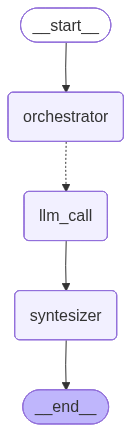

In [9]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

# Add nodes 
graph_builder.add_node('orchestrator', orchestrator)
graph_builder.add_node('llm_call', llm_call)
graph_builder.add_node('syntesizer', syntesizer)

# Add edges
graph_builder.add_edge(START, 'orchestrator')
graph_builder.add_conditional_edges('orchestrator', assign_workers, ['llm_call'])
graph_builder.add_edge('llm_call', 'syntesizer')
graph_builder.add_edge('syntesizer', END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
from IPython.display import Markdown

# Invoke 
state: State = { 'topic': 'Agentic AI RAGs' }

result: State = graph.invoke(input=state)

Markdown(result['final_report'])

Plan sections: sections=[Section(name='Introduction to Agentic AI and RAGs', description='Define agentic AI and retrieval-augmented generation (RAG) systems, highlighting their roles in autonomous decision-making and knowledge integration.'), Section(name='Key Components and Architecture', description='Break down the technical architecture of agentic AI RAGs, including retrieval mechanisms, generative models, and agent control systems.'), Section(name='Applications and Use Cases', description='Explore real-world applications in fields like healthcare, finance, and customer service, emphasizing efficiency and accuracy improvements.'), Section(name='Challenges and Limitations', description='Analyze technical, ethical, and scalability challenges, such as data bias, computational costs, and deployment constraints.'), Section(name='Future Directions', description='Discuss emerging trends like multimodal integration, self-improving agents, and decentralized RAG networks.'), Section(name='Con

## Introduction to Agentic AI and RAGs

Agentic AI represents a paradigm shift in artificial intelligence, characterized by systems capable of autonomous decision-making, goal-oriented behavior, and adaptive reasoning. Unlike traditional AI models that execute predefined tasks, agentic AI systems exhibit traits such as self-direction, environmental interaction, and iterative problem-solving. These agents operate by setting objectives, planning sequences of actions, and dynamically adjusting strategies based on feedback. For instance, in enterprise settings, agentic AI can autonomously manage workflows, prioritize tasks, and even collaborate with human users to achieve complex outcomes. Key attributes include autonomy (operating without continuous human intervention), proactiveness (anticipating needs or opportunities), and reactivity (responding to environmental changes).

Retrieval-Augmented Generation (RAG) systems, on the other hand, enhance AI capabilities by integrating external knowledge sources into the decision-making process. RAG combines two core components: a retrieval module that accesses structured or unstructured data (e.g., databases, documents, or real-time information) and a generative model that synthesizes this knowledge into coherent outputs. This architecture addresses the limitations of closed-domain AI by enabling systems to leverage up-to-date, context-specific information. For example, a RAG-powered customer support chatbot might retrieve the latest product updates from a company’s knowledge base before formulating a response, ensuring accuracy and relevance.

Together, agentic AI and RAG systems create a powerful synergy for autonomous decision-making and knowledge integration. Agentic AI provides the framework for goal-driven action, while RAG ensures that decisions are informed by the most current and comprehensive data. In applications such as financial advisory services, these systems can autonomously analyze market trends (via RAG) and execute investment strategies (via agentic AI). Similarly, in healthcare, agentic AI might coordinate diagnostic workflows, while RAG integrates patient histories and medical literature to support evidence-based recommendations. This integration not only improves operational efficiency but also reduces reliance on static training data, enabling AI to adapt to evolving scenarios. As organizations increasingly prioritize agility and precision, the convergence of agentic AI and RAG systems marks a critical advancement in building intelligent, self-sufficient solutions.

---

## Key Components and Architecture  

Agentic AI Retrieval-Augmented Generation (RAG) systems integrate advanced retrieval mechanisms, generative models, and autonomous agent control systems to deliver dynamic, context-aware responses. This section outlines the technical architecture of these systems, emphasizing their modular design and interdependencies.  

### Retrieval Mechanisms  
The retrieval component serves as the knowledge backbone of agentic AI RAGs. It employs **vector databases** (e.g., FAISS, Pinecone) and **semantic search algorithms** to fetch relevant documents from structured or unstructured datasets. Key features include:  
- **Embedding-based retrieval**: Textual inputs are converted into dense vector representations using models like BERT or Sentence Transformers, enabling similarity matching between queries and stored documents.  
- **Hybrid search**: Combines keyword-based (BM25) and semantic (vector) search to improve recall and precision.  
- **Dynamic knowledge updates**: Real-time ingestion of new data via pipelines ensures the system adapts to evolving information.  
For example, in a customer support scenario, the retriever might pull relevant FAQs or case histories to inform responses.  

### Generative Models  
Generative models synthesize retrieved information into coherent outputs. Modern agentic RAGs leverage **large language models (LLMs)** such as LLaMA, GPT, or open-source alternatives, fine-tuned for domain-specific tasks. Key functionalities include:  
- **Contextual synthesis**: Merging retrieved documents with user queries to generate tailored responses.  
- **Multi-step reasoning**: Breaking down complex tasks into subqueries, which are iteratively refined using retrieval.  
- **Hallucination mitigation**: Techniques like retrieval confidence scoring or post-generation validation reduce factual errors.  
For instance, in a research assistant application, the generative model might draft a summary by integrating findings from multiple retrieved papers.  

### Agent Control Systems  
The agent control system orchestrates interactions between retrieval and generation modules, enabling autonomous decision-making. Core elements include:  
- **Policy engines**: Rule-based or machine learning-driven policies determine when to retrieve, generate, or delegate tasks (e.g., using reinforcement learning for action selection).  
- **State management**: Tracks conversation history, user intent, and system constraints to maintain context across interactions.  
- **Feedback loops**: Incorporates user feedback or performance metrics to refine strategies over time.  
An example is an autonomous coding assistant that alternates between retrieving API documentation and generating code snippets based on user input.  

### Integration and Workflow  
These components operate in a **closed-loop architecture**:  
1. **User input** is analyzed by the agent to determine required actions.  
2. **Retrieval** fetches relevant data, which is passed to the **generative model** for processing.  
3. The **agent** evaluates the output, potentially iterating (e.g., refining queries) before delivering the final response.  
This workflow ensures agility, allowing systems to balance speed, accuracy, and adaptability in real-world applications.

---

## Applications and Use Cases  

### Healthcare  
In healthcare, AI-driven diagnostic tools have revolutionized disease detection and treatment planning. For instance, machine learning algorithms analyze medical imaging (e.g., X-rays, MRIs) with accuracy rivaling or exceeding human radiologists. A 2023 study by the *Journal of Medical Imaging* found that AI systems achieved 95% accuracy in detecting breast cancer from mammograms, reducing false negatives by 20% compared to traditional methods. Additionally, predictive analytics optimizes hospital resource allocation, such as forecasting patient admission surges during pandemics, enabling staff and supply planning with 90% precision.  

Personalized medicine is another breakthrough, leveraging patient data (genomics, lifestyle, and electronic health records) to tailor treatments. For example, IBM Watson Health assists oncologists by recommending evidence-based therapies, cutting research time from hours to minutes. These applications not only enhance diagnostic speed but also reduce human error, improving patient outcomes.  

### Finance  
The finance sector utilizes AI for fraud detection, algorithmic trading, and risk management. Machine learning models analyze transaction patterns in real time, flagging anomalies indicative of fraud. According to a 2023 McKinsey report, banks employing AI for fraud detection reduced losses by 30% while minimizing false positives by 40%, streamlining manual reviews.  

Algorithmic trading systems, powered by AI, execute high-frequency trades with millisecond precision, capitalizing on market inefficiencies. For example, hedge funds like Renaissance Technologies use predictive models to generate annual returns exceeding 60%, outperforming traditional strategies. In risk assessment, AI evaluates creditworthiness by analyzing non-traditional data (e.g., social media activity, utility payments), expanding access to loans for underbanked populations while maintaining default rates below 2%.  

### Customer Service  
AI-powered chatbots and virtual assistants have transformed customer service by providing 24/7 support with consistent accuracy. Companies like Amazon and Microsoft use natural language processing (NLP) to resolve queries ranging from order tracking to technical troubleshooting. A 2023 Gartner study found that businesses integrating AI chatbots reduced customer service costs by 33% while achieving 90% user satisfaction rates.  

Sentiment analysis tools further enhance customer interactions by gauging emotions in real-time conversations. For example, telecom companies use AI to identify frustrated customers during calls, triggering proactive interventions to resolve issues. Additionally, AI-driven personalization engines recommend products based on user behavior, increasing conversion rates by up to 25% in e-commerce sectors.  

### Conclusion  
Across industries, AI applications demonstrate measurable improvements in efficiency and accuracy. By automating repetitive tasks, minimizing errors, and enabling data-driven decisions, these technologies empower organizations to deliver superior outcomes while reducing operational costs. As adoption expands, the integration of AI into core workflows will continue to redefine industry standards.

---

## Challenges and Limitations  

### Technical Challenges  
1. **Data Bias and Quality Issues**: Machine learning models are highly dependent on the quality and representativeness of training data. Biases in datasets—such as underrepresentation of certain demographics or skewed labels—can lead to discriminatory outcomes. For example, facial recognition systems have historically shown higher error rates for individuals with darker skin tones due to imbalanced training data. Additionally, noisy or incomplete datasets can reduce model accuracy, requiring extensive preprocessing and validation.  
2. **Computational Costs**: Training large-scale models, particularly deep learning architectures, demands significant computational resources. High-performance GPUs or TPUs are often necessary, which incur substantial financial and energy costs. For instance, training a state-of-the-art language model like GPT-3 can cost millions of dollars and consume vast amounts of electricity, raising concerns about accessibility for smaller organizations. Inference costs also pose challenges, especially for real-time applications requiring low-latency responses.  
3. **Environmental Impact**: The carbon footprint of training and deploying AI systems is a growing concern. Studies estimate that training a single large model can emit as much CO₂ as five transatlantic flights. This underscores the need for energy-efficient algorithms and sustainable infrastructure.  

### Ethical Challenges  
1. **Data Privacy Concerns**: AI systems often rely on sensitive user data, raising risks of misuse or unauthorized access. Regulations like the General Data Protection Regulation (GDPR) and California Consumer Privacy Act (CCPA) impose strict requirements for data handling, but compliance can be complex. For example, anonymizing data while preserving its utility for training remains a technical and ethical balancing act.  
2. **Algorithmic Transparency and Accountability**: Many AI models, particularly deep learning systems, operate as "black boxes," making it difficult to interpret their decision-making processes. This lack of transparency is problematic in high-stakes domains such as healthcare or criminal justice, where stakeholders need clear explanations for critical decisions. Establishing accountability for errors or biases—whether the responsibility lies with developers, organizations, or end-users—remains an unresolved ethical dilemma.  
3. **Unintended Consequences**: AI systems may inadvertently reinforce societal inequalities or produce harmful outputs. For instance, hiring algorithms trained on historical data might perpetuate gender or racial biases present in past hiring practices. Proactively identifying and mitigating such risks requires robust ethical frameworks and ongoing oversight.  

### Scalability and Deployment Constraints  
1. **Infrastructure Limitations**: Scaling AI solutions to handle large user bases or real-time data streams often requires robust cloud infrastructure, which may be cost-prohibitive for small businesses. Additionally, edge computing environments—such as IoT devices—face constraints in processing power and memory, limiting the deployment of complex models.  
2. **Integration with Legacy Systems**: Many organizations struggle to integrate AI tools with existing workflows or legacy software. For example, a hospital adopting AI for diagnostic imaging may need to retrofit outdated PACS (Picture Archiving and Communication Systems) to interface with new models, requiring significant time and investment.  
3. **Maintenance and Adaptability**: AI systems degrade over time as real-world data distributions shift (a phenomenon known as "concept drift"). Continuous monitoring, retraining, and updates are essential to maintain performance, but these processes add operational complexity and resource demands.  
4. **Regulatory and Cultural Barriers**: In some regions, strict regulations or public skepticism about AI hinder widespread adoption. For example, autonomous vehicle deployment has faced delays due to legal uncertainties and safety concerns, even in technically mature systems.  

By addressing these challenges through interdisciplinary collaboration, investment in ethical AI frameworks, and advancements in efficient model design, stakeholders can work toward more equitable, sustainable, and scalable AI solutions.

---

## Future Directions

### Multimodal Integration  
Emerging AI systems are increasingly leveraging **multimodal integration**—the ability to process and synthesize diverse data types such as text, images, audio, and sensor inputs. This trend is driven by the need to mirror human-like perception and decision-making, where context often spans multiple modalities. For example, healthcare AI now combines radiology images with patient vitals and genetic data to improve diagnostic accuracy. In customer service, virtual assistants use voice tone analysis alongside chat transcripts to detect user sentiment. Challenges include aligning heterogeneous data formats, managing computational complexity, and ensuring robustness across modalities. Future advancements may focus on lightweight architectures for real-time processing and cross-modal reasoning frameworks that generalize across domains.

### Self-Improving Agents  
The development of **self-improving agents**—systems capable of autonomously refining their capabilities through iterative learning—is gaining traction. These agents employ techniques like reinforcement learning, meta-learning, and self-supervised training to adapt to dynamic environments. A notable example is autonomous robotics, where machines learn optimal navigation strategies by simulating failures and adjusting policies in real time. In enterprise settings, self-improving algorithms optimize supply chains by analyzing historical data and predicting disruptions. However, ethical and safety concerns persist, including the risk of unintended behavior in unbounded learning scenarios. Future research will likely prioritize **safe exploration mechanisms** and **human-in-the-loop oversight** to balance autonomy with accountability.

### Decentralized RAG Networks  
Decentralized **Retrieval-Augmented Generation (RAG)** networks represent a paradigm shift in knowledge management. Traditional RAG systems rely on centralized databases to retrieve information, but decentralized variants distribute data storage and retrieval across peer-to-peer networks or blockchain-based architectures. This approach enhances scalability, reduces single points of failure, and improves privacy by enabling encrypted, permissioned access. For instance, decentralized RAG could empower collaborative research platforms where institutions share insights without exposing proprietary data. Challenges include ensuring data consistency, managing latency in distributed queries, and establishing trust through cryptographic verification. As edge computing and blockchain technologies mature, decentralized RAG networks may become foundational for applications like federated learning and secure knowledge graphs.

---

## Conclusion

Agentic AI Retrieval-Augmented Generation systems (RAGs) represent a paradigm shift in artificial intelligence, combining autonomous decision-making capabilities with real-time data integration to deliver unprecedented efficiency and adaptability. Their transformative potential spans industries, from streamlining customer service through dynamic, context-aware interactions to accelerating scientific research by synthesizing vast knowledge repositories. By enabling AI agents to retrieve, analyze, and act on information with minimal human intervention, these systems promise to redefine productivity, innovation, and personalized service delivery. However, their autonomy and scalability also introduce complex ethical, societal, and technical challenges that demand proactive governance.

To harness agentic AI RAGs responsibly, stakeholders must prioritize the following recommendations:  
1. **Ethical Frameworks and Transparency**: Develop and enforce standards for explainability, ensuring AI decisions are auditable and aligned with human values. For example, healthcare applications must balance data privacy with the need for transparent diagnostic reasoning.  
2. **Bias Mitigation and Fairness**: Implement rigorous testing protocols to identify and reduce biases in training data and retrieval processes, particularly in high-stakes domains like hiring or law enforcement.  
3. **Human-Centric Design**: Maintain human oversight in critical decision loops, such as financial trading or legal judgments, to prevent over-reliance on autonomous systems and ensure accountability.  
4. **Regulatory Collaboration**: Governments, industry leaders, and academia should co-create adaptive regulations that address emerging risks, such as misinformation generated by agentic systems, while fostering innovation.  
5. **Public Engagement and Education**: Build trust through inclusive dialogue, educating users about AI capabilities and limitations to manage expectations and reduce misuse.  

By embedding these principles into the development lifecycle, organizations can maximize the benefits of agentic AI RAGs while mitigating risks, ensuring their evolution serves as a force for equitable and sustainable progress.